## Tree-Based Modeling: XGBoost (Basic model)

In [ ]:
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [40]:
df = pd.read_csv("../data/processed/features_dataset.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

In [41]:
train = df[df["timestamp"] < "2026-01-01"].copy()
test = df[df["timestamp"] >= "2026-01-01"].copy()

In [42]:
target = "price"

drop_cols = ["timestamp", target]

feature_cols = [col for col in df.columns if col not in drop_cols]

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

In [43]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [44]:
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost MAE: {xgb_mae:.3f}")

XGBoost MAE: 10.727


In [45]:
# Train predictions
xgb_train_pred = xgb_model.predict(X_train)

train_mae = mean_absolute_error(y_train, xgb_train_pred)

print(f"Train MAE: {train_mae:.3f}")
print(f"Test MAE: {xgb_mae:.3f}")

Train MAE: 6.685
Test MAE: 10.727


In [46]:
xgb_results = test[["timestamp", "price"]].copy()
xgb_results["xgb_prediction"] = xgb_pred

xgb_results.to_csv("../outputs/predictions/xgb_basic_predictions.csv", index=False)

xgb_results.head()

,timestamp,price,xgb_prediction
26133,2026-01-01 00:00:00,58.28,46.095058
26134,2026-01-01 01:00:00,42.40,22.206049
26135,2026-01-01 02:00:00,19.57,11.053576
26136,2026-01-01 03:00:00,6.29,6.239372
26137,2026-01-01 04:00:00,3.09,3.648710


## Improve XGBoost

In [ ]:
train_full = df[df["timestamp"] < "2026-01-01"].copy()
test = df[df["timestamp"] >= "2026-01-01"].copy()

# Split train into train + validation
train = train_full[train_full["timestamp"] < "2025-12-01"].copy()
val = train_full[train_full["timestamp"] >= "2025-12-01"].copy()

In [48]:
target = "price"
drop_cols = ["timestamp", target]

feature_cols = [col for col in df.columns if col not in drop_cols]

X_train = train[feature_cols]
y_train = train[target]

X_val = val[feature_cols]
y_val = val[target]

X_test = test[feature_cols]
y_test = test[target]

In [58]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [59]:
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost MAE: {xgb_mae:.3f}")

XGBoost MAE: 10.854


In [60]:
xgb_train_pred = xgb_model.predict(X_train)

train_mae = mean_absolute_error(y_train, xgb_train_pred)

print(f"Train MAE: {train_mae:.3f}")
print(f"Test MAE: {xgb_mae:.3f}")

Train MAE: 4.861
Test MAE: 10.854


Overfitting in original and also on changing hyperparameters. Underfitting on adding early stopping+validation.

Therefore we will remove weak and useless features.


In [61]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
3,forecasted_residual_load,0.316427
1,actual_residual_load,0.277661
23,lag_24,0.060538
25,lag_168,0.033305
7,actual_wind_onshore,0.029394
11,actual_fossil_gas,0.027579
9,actual_lignite,0.019328
12,actual_wind_total,0.014076
24,lag_48,0.013648
20,month,0.013306


In [62]:
feature_importance.tail(15)

,feature,importance
32,actual_load_lag_168,0.003848
31,actual_load_lag_48,0.003492
27,rolling_std_24,0.003445
41,actual_solar_lag_168,0.003426
37,actual_wind_total_lag_48,0.003026
22,hour_cos,0.002988
21,hour_sin,0.002878
0,actual_load,0.002748
18,hour,0.002665
43,actual_renewable_total_lag_48,0.002570


In [63]:
train = df[df["timestamp"] < "2026-01-01"].copy()
test = df[df["timestamp"] >= "2026-01-01"].copy()

In [64]:
target = "price"

drop_cols = ["timestamp", target]

remove_features = [
    "actual_load",
    "forecasted_load",
    "hour",
    "hour_sin",
    "hour_cos",
    "rolling_std_24",
    
    "actual_load_lag_24",
    "actual_load_lag_48",
    "actual_load_lag_168",
    
    "actual_renewable_total_lag_24",
    "actual_renewable_total_lag_48",
    "actual_renewable_total_lag_168",
    
    "actual_solar_lag_24",
    "actual_solar_lag_48",
    "actual_solar_lag_168",
    
    "actual_wind_total_lag_48"
]

feature_cols = [
    col for col in df.columns
    if col not in drop_cols and col not in remove_features
]

print("Remaining features:", len(feature_cols))


X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

Remaining features: 32


In [65]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [66]:
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_train_pred = xgb_model.predict(X_train)

train_mae = mean_absolute_error(y_train, xgb_train_pred)

print(f"Train MAE: {train_mae:.3f}")
print(f"Test MAE: {xgb_mae:.3f}")

Train MAE: 5.191
Test MAE: 10.422


## Bayesian Optimization

In [82]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [83]:
target = "price"
drop_cols = ["timestamp", target]

remove_features = [
    "actual_load",
    "forecasted_load",
    "hour",
    "hour_sin",
    "hour_cos",
    "rolling_std_24",

    "actual_load_lag_24",
    "actual_load_lag_48",
    "actual_load_lag_168",

    "actual_renewable_total_lag_24",
    "actual_renewable_total_lag_48",
    "actual_renewable_total_lag_168",

    "actual_solar_lag_24",
    "actual_solar_lag_48",
    "actual_solar_lag_168",

    "actual_wind_total_lag_48"
]

feature_cols = [
    col for col in df.columns
    if col not in drop_cols and col not in remove_features
]

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

print("Number of selected features:", len(feature_cols))
print(X_train.columns.equals(X_test.columns))

Number of selected features: 32
True


In [84]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.08),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.95),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "random_state": 42
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    return mean_absolute_error(y_test, preds)

In [85]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

[I 2026-04-29 13:56:30,693] A new study created in memory with name: no-name-cd6763f4-3ffb-41ec-beb1-d767de39a0c1
[I 2026-04-29 13:56:31,622] Trial 0 finished with value: 10.663354391897718 and parameters: {'n_estimators': 325, 'learning_rate': 0.05255753616885321, 'max_depth': 5, 'subsample': 0.8932866275660757, 'colsample_bytree': 0.795811639147107, 'reg_alpha': 0.22410474790605694, 'reg_lambda': 1.3550505857866102}. Best is trial 0 with value: 10.663354391897718.
[I 2026-04-29 13:56:32,416] Trial 1 finished with value: 10.868359616511812 and parameters: {'n_estimators': 362, 'learning_rate': 0.03357565756364241, 'max_depth': 4, 'subsample': 0.7849770115213119, 'colsample_bytree': 0.8589179924110691, 'reg_alpha': 0.2917395404040998, 'reg_lambda': 6.1257664963613685}. Best is trial 0 with value: 10.663354391897718.
[I 2026-04-29 13:56:33,142] Trial 2 finished with value: 10.43906741026044 and parameters: {'n_estimators': 245, 'learning_rate': 0.06692899456938595, 'max_depth': 5, 'subs

In [86]:
print("Best parameters:")
print(study.best_params)

Best parameters:
{'n_estimators': 393, 'learning_rate': 0.05959350587956254, 'max_depth': 6, 'subsample': 0.7441448793380832, 'colsample_bytree': 0.8728385442373922, 'reg_alpha': 0.6650896112616075, 'reg_lambda': 3.4837761416290904}


In [87]:
best_params = study.best_params

final_model = XGBRegressor(**best_params)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)

print(f"Final XGBoost MAE: {final_mae:.3f}")

Final XGBoost MAE: 9.593


In [88]:
train_pred = final_model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)

print(f"Train MAE: {train_mae:.3f}")
print(f"Test MAE: {final_mae:.3f}")

Train MAE: 5.392
Test MAE: 9.593


In [90]:
final_xgb_results = test[["timestamp", "price"]].copy()
final_xgb_results["prediction"] = final_pred
final_xgb_results["absolute_error"] = abs(
    final_xgb_results["price"] - final_xgb_results["prediction"]
)

final_xgb_results.to_csv(
    "../outputs/predictions/final_xgb_bayesian_predictions.csv",
    index=False
)

final_xgb_results.head()

,timestamp,price,prediction,absolute_error
26133,2026-01-01 00:00:00,58.28,49.071453,9.208547
26134,2026-01-01 01:00:00,42.40,25.857014,16.542986
26135,2026-01-01 02:00:00,19.57,14.999722,4.570278
26136,2026-01-01 03:00:00,6.29,13.930622,7.640622
26137,2026-01-01 04:00:00,3.09,14.277108,11.187108


In [94]:
selected_features = pd.DataFrame({"feature": feature_cols})

selected_features.to_csv(
    "../outputs/tables/selected_features_xgb.csv",
    index=False
)

selected_features

,feature
0,actual_residual_load
1,forecasted_residual_load
2,actual_biomass
3,actual_hydropower
4,actual_wind_offshore
5,actual_wind_onshore
6,actual_solar
7,actual_lignite
8,actual_hard_coal
9,actual_fossil_gas


In [96]:
import matplotlib.pyplot as plt

comparison_plot = test[["timestamp", "price"]].copy()

comparison_plot["xgb_simple_prediction"] = xgb_pred
comparison_plot["xgb_bayesian_prediction"] = final_pred

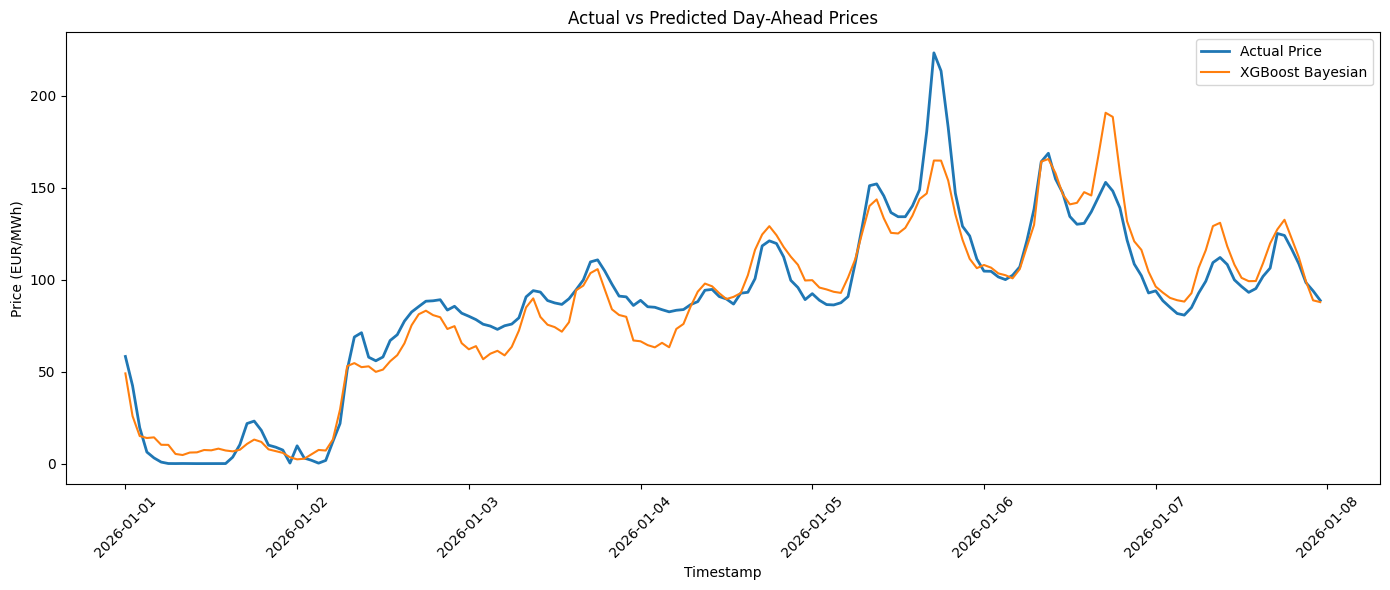

In [ ]:
plot_data = comparison_plot[
    (comparison_plot["timestamp"] >= "2026-01-01") &
    (comparison_plot["timestamp"] < "2026-01-08")
].copy()

plt.figure(figsize=(14, 6))

plt.plot(plot_data["timestamp"], plot_data["price"], label="Actual Price", linewidth=2)
#plt.plot(plot_data["timestamp"], plot_data["xgb_simple_prediction"], label="XGBoost Simple")
plt.plot(plot_data["timestamp"], plot_data["xgb_bayesian_prediction"], label="XGBoost Bayesian")

plt.title("Actual vs Predicted Day-Ahead Prices")
plt.xlabel("Timestamp")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/figures/actual_vs_xgboost_prediction.png", dpi=300)
plt.show()